# Лабораторная работа по теме: «Классификация с помощью нейронных сетей»

### Задание
Построить двухслойную нейронную сеть для классификации на два класса. Разбивку на классы сделать  по столбцу "правильных ответов". Если этот столбец непонятно как определить (можно спросить о нем у преподавателя), то использовать  разбиение на 2 кластера в задании 2 или 3. Классификацию проводить по всем признакам, а для визуализации использовать два наиболее значимых или главные компоненты из 3. (Вариант архитектуры сети - оба слоя полносвязных, первый слой с функцией активации Релу, а второй слой софтмакс или сигмоидная функция активации. Качество можно отслеживать с помощью точности, эпох должно быть не меньше 10; по поводу использования библиотек: можно написать не используя специальных библиотек для разработки нейронных сетей; можно использовать библиотеки, лучше использовать tensorflow и keras в Colab.

### Подключение необходимых библиотек и загрузка датасета данных

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

df = pd.read_csv('/content/adult.csv')
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Предобработка данных

In [29]:
columns_for_clustering = [
    'age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week',
    'workclass', 'education', 'marital-status', 'occupation',
    'relationship', 'race', 'sex', 'native-country'
]
df = df[columns_for_clustering + ['salary']]
df = df.replace(' ?', np.nan).dropna().reset_index(drop=True)
print(f"Размер данных после очистки: {df.shape}")

# Кодирование категориальных признаков
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation',
                    'relationship', 'race', 'sex', 'native-country']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Матрица признаков
X = df[columns_for_clustering].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Предобработка данных завершена")

Размер данных после очистки: (32561, 14)
Предобработка данных завершена


### Получение целевой переменной

In [30]:
# Применяем PCA (2 компоненты) и KMeans (2 кластера)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

kmeans_pca = KMeans(n_clusters=2, random_state=42, n_init=10)
y = kmeans_pca.fit_predict(X_pca)

print("Распределение кластеров:")
print(pd.Series(y).value_counts())
df['Cluster'] = y

Распределение кластеров:
1    18586
0    13975
Name: count, dtype: int64


### Разделение данных на обучающую и тестовую выборки

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

Размер обучающей выборки: 22792
Размер тестовой выборки: 9769


### Построение двухслойной нейронной сети

In [33]:
# Архитектура сети:
# cлой 1: 64 нейрона
# cлой 2: 1 нейрон

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],), name='Hidden_Layer_ReLU'),
    Dense(1, activation='sigmoid', name='Output_Layer_Sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Архитектура нейронной сети:")
model.summary()

Архитектура нейронной сети:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_ReLU (Dense)       │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer_Sigmoid (Dense)    │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

### Обучение сети

In [34]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    verbose=1
)

Epoch 1/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9609 - loss: 0.1491 - val_accuracy: 0.9921 - val_loss: 0.0470
Epoch 2/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9941 - loss: 0.0369 - val_accuracy: 0.9950 - val_loss: 0.0286
Epoch 3/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9955 - loss: 0.0251 - val_accuracy: 0.9954 - val_loss: 0.0220
Epoch 4/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9963 - loss: 0.0197 - val_accuracy: 0.9961 - val_loss: 0.0184
Epoch 5/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9964 - loss: 0.0166 - val_accuracy: 0.9961 - val_loss: 0.0161
Epoch 6/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9968 - loss: 0.0144 - val_accuracy: 0.9965 - val_loss: 0.0145
Epoch 7/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9972 - loss: 0.0127 - val_accuracy: 0.9965 - val_loss: 0.0133
Epoch 8/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9973 - loss: 0.0115 - val_accuracy: 0.

### Оценка качества классификации

In [38]:
# Предсказания на тестовой выборке
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Метрики
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nОценка качества на тестовой выборке:")
print(f"   Accuracy:  {acc:.4f}")
print(f"   Precision: {prec:.4f}")
print(f"   Recall:    {rec:.4f}")
print(f"   F1-score:  {f1:.4f}")

print("\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred))

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Оценка качества на тестовой выборке:
   Accuracy:  0.9971
   Precision: 0.9968
   Recall:    0.9982
   F1-score:  0.9975

Матрица ошибок:
[[4175   18]
 [  10 5566]]


### Графики обучения

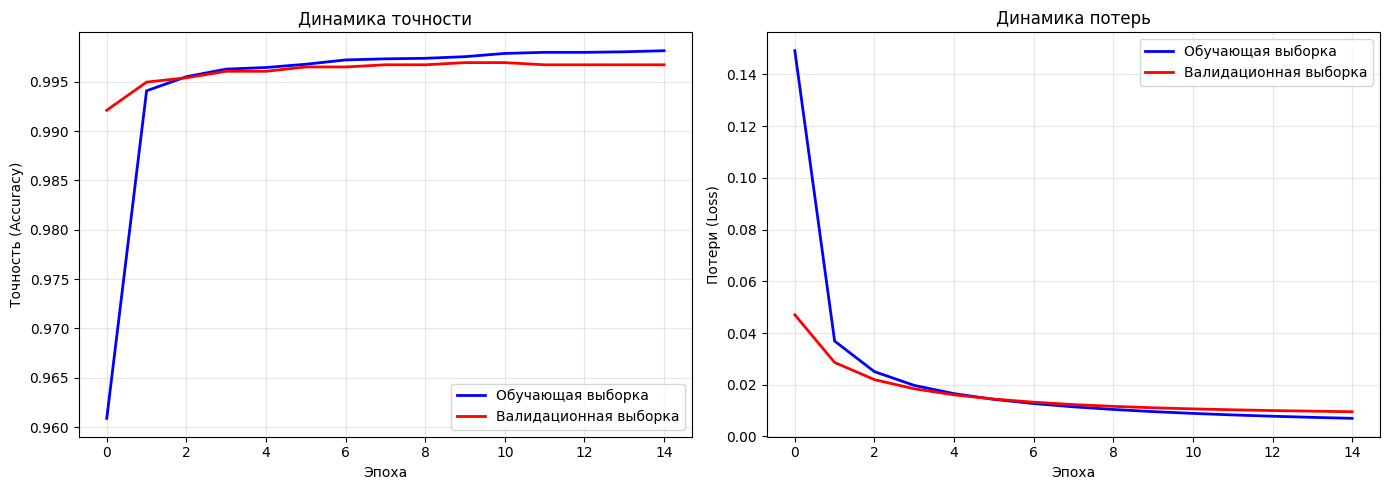

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Точность
axes[0].plot(history.history['accuracy'], 'b-', label='Обучающая выборка', linewidth=2)
axes[0].plot(history.history['val_accuracy'], 'r-', label='Валидационная выборка', linewidth=2)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Точность (Accuracy)')
axes[0].set_title('Динамика точности')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Потери
axes[1].plot(history.history['loss'], 'b-', label='Обучающая выборка', linewidth=2)
axes[1].plot(history.history['val_loss'], 'r-', label='Валидационная выборка', linewidth=2)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Потери (Loss)')
axes[1].set_title('Динамика потерь')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Визуализация с использованием главных компонент (PCA)

1018/1018 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


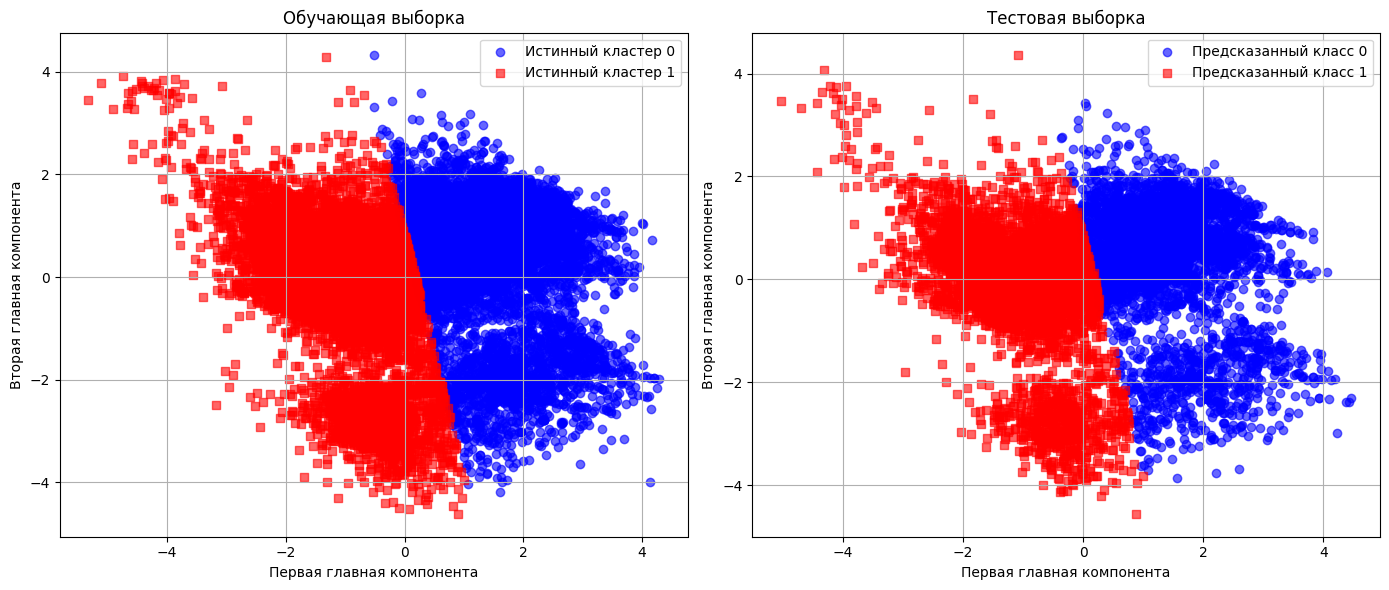

In [37]:
# Предсказания для всех данных
y_all_pred_prob = model.predict(X_scaled)
y_all_pred = (y_all_pred_prob > 0.5).astype(int).flatten()

# Разделение на обучающие и тестовые точки
indices_train = np.arange(len(X_scaled))[:len(X_train)]
indices_test = np.arange(len(X_scaled))[len(X_train):]
colors = {0: 'blue', 1: 'red'}
markers = {0: 'o', 1: 's'}
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for class_id in [0, 1]:
    idx = (y == class_id) & (np.arange(len(y)) < len(X_train))
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                c=colors[class_id], marker=markers[class_id],
                label=f'Истинный кластер {class_id}', alpha=0.6)
plt.title('Обучающая выборка')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for class_id in [0, 1]:
    idx = (y_all_pred == class_id) & (np.arange(len(y)) >= len(X_train))
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                c=colors[class_id], marker=markers[class_id],
                label=f'Предсказанный класс {class_id}', alpha=0.6)
plt.title('Тестовая выборка')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Вывод
Выполняя лабораторную работу, была построена двухслойная нейросеть, обученная за 15 эпох. При тестировании достигнуты следующие показатели: Accuracy = 99.71, Precision = 99.68, Recall = 99.82, F1-score = 99.75. Модель допустила 28 ошибок на 9769 образцах.